In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
adata = sc.datasets.pbmc3k()

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

In [4]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [5]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

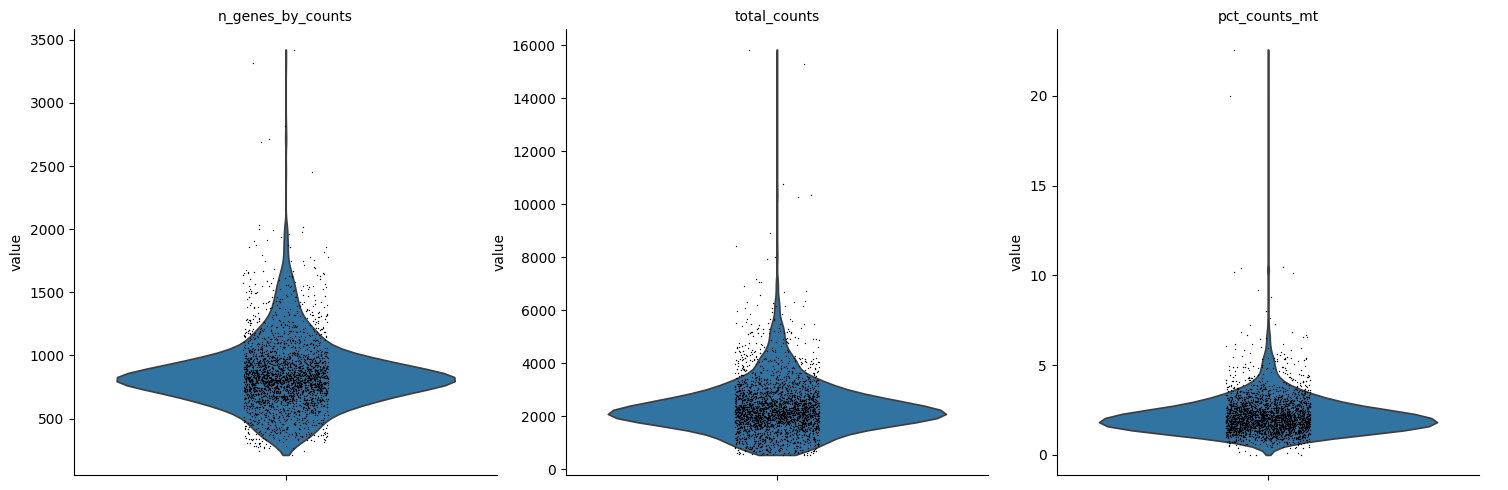

In [6]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    multi_panel=True
)

In [7]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[adata.obs.pct_counts_mt < 5]

In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/home/sudharshini/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


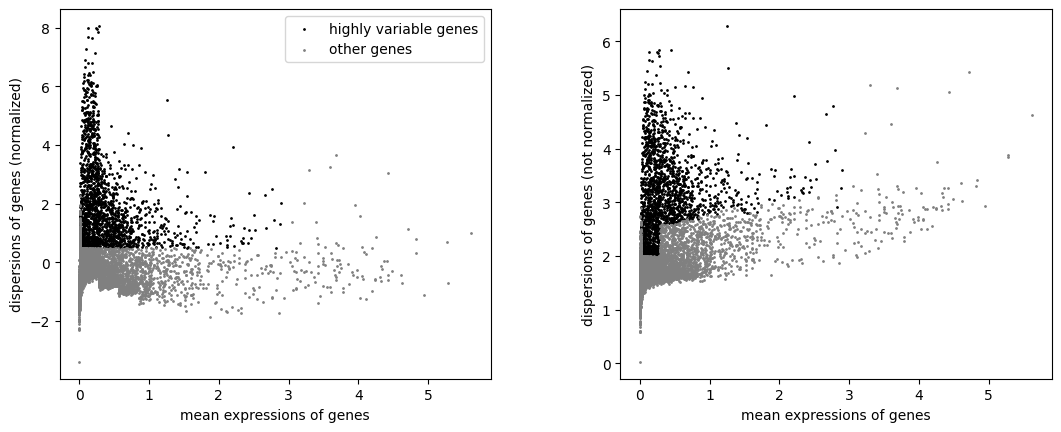

In [9]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

sc.pl.highly_variable_genes(adata)

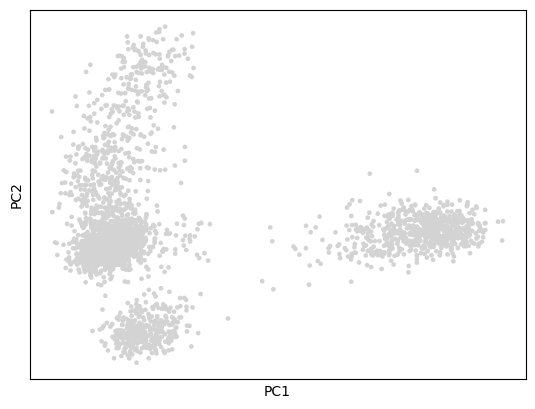

In [10]:
sc.tl.pca(adata)

sc.pl.pca(adata)

In [11]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

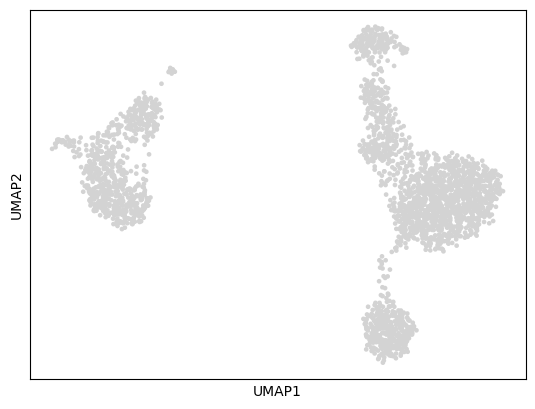

In [12]:
sc.tl.umap(adata)

sc.pl.umap(adata)

/tmp/ipykernel_6241/2734984316.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


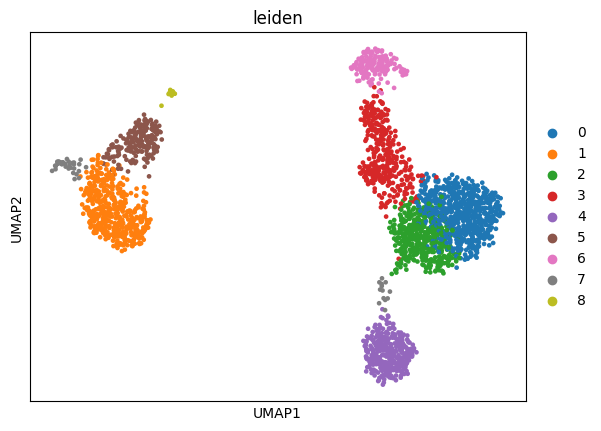

In [13]:
sc.tl.leiden(adata)

sc.pl.umap(
    adata,
    color=['leiden']
)

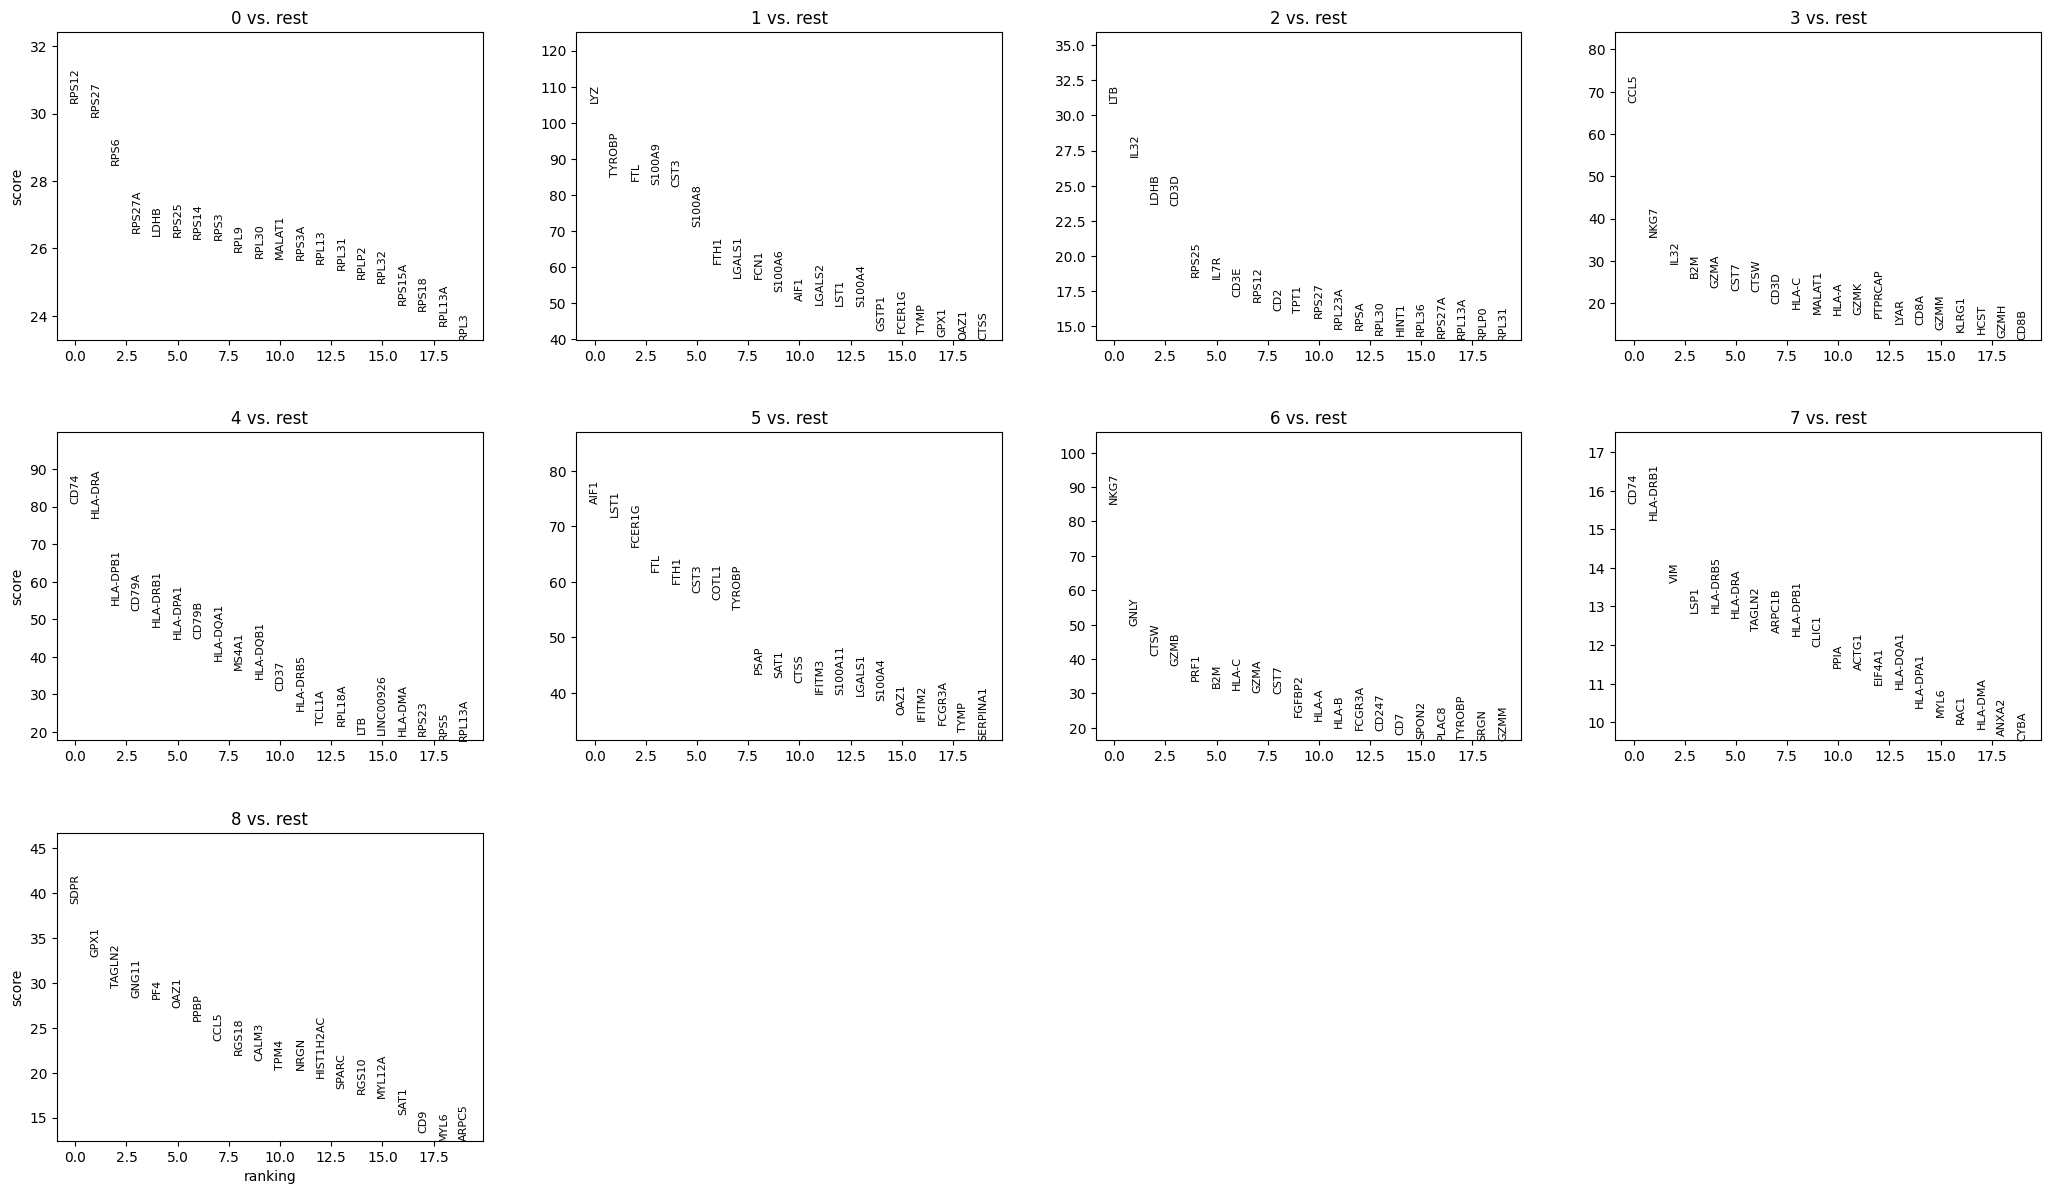

In [14]:
sc.tl.rank_genes_groups(
    adata,
    'leiden',
    method='t-test'
)

sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False
)

In [16]:
import os

os.makedirs("results", exist_ok=True)

In [18]:
adata.write("../results/pbmc_analysis.h5ad")

In [19]:
sc.settings.figdir = "figures"

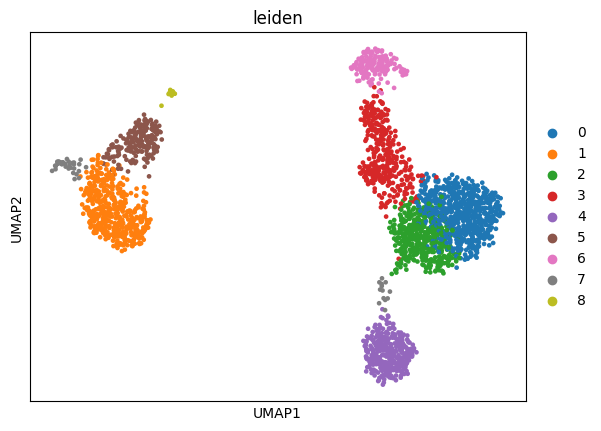

In [20]:
sc.pl.umap(
    adata,
    color='leiden',
    save="_clusters.png"
)